# Proyek Analisis Data: E-Commerce Public Dataset
- **Nama:** I Gede Surya Diva Ananda
- **Email:** gedesuryadiva@gmail.com
- **ID Dicoding:** divaananda

## Menentukan Pertanyaan Bisnis

Pada proyek ini, akan dilakukan analisis data dari dataset E-Commerce Public (Olist - Brazilian E-Commerce) untuk menjawab dua pertanyaan bisnis berikut:

1. **Bagaimana segmentasi pelanggan berdasarkan perilaku pembelian menggunakan RFM Analysis, dan berapa proporsi setiap segmen?**
   - Recency: Seberapa baru pelanggan melakukan pembelian terakhir?
   - Frequency: Seberapa sering pelanggan melakukan pembelian?
   - Monetary: Berapa total pengeluaran pelanggan?

2. **Bagaimana distribusi geografis pelanggan dan seller, serta bagaimana lokasi memengaruhi volume pesanan?**
   - Di mana konsentrasi pelanggan terbanyak?
   - Di mana seller paling banyak berlokasi?
   - Apakah ada korelasi antara lokasi dengan performa penjualan?

## Import Semua Packages/Library yang Digunakan

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import folium
from folium.plugins import MarkerCluster
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

## Data Wrangling

### Gathering Data

Pada tahap ini, kita akan memuat seluruh dataset yang tersedia. Dataset E-Commerce Public terdiri dari 9 file CSV yang saling berhubungan.

In [2]:
# Load semua dataset
customers_df = pd.read_csv('data/customers_dataset.csv')
orders_df = pd.read_csv('data/orders_dataset.csv')
order_items_df = pd.read_csv('data/order_items_dataset.csv')
order_payments_df = pd.read_csv('data/order_payments_dataset.csv')
order_reviews_df = pd.read_csv('data/order_reviews_dataset.csv')
products_df = pd.read_csv('data/products_dataset.csv')
sellers_df = pd.read_csv('data/sellers_dataset.csv')
geolocation_df = pd.read_csv('data/geolocation_dataset.csv')
category_translation_df = pd.read_csv('data/product_category_name_translation.csv')

In [3]:
# Cek ukuran masing-masing dataset
datasets = {
    'customers': customers_df,
    'orders': orders_df,
    'order_items': order_items_df,
    'order_payments': order_payments_df,
    'order_reviews': order_reviews_df,
    'products': products_df,
    'sellers': sellers_df,
    'geolocation': geolocation_df,
    'category_translation': category_translation_df
}

for name, df in datasets.items():
    print(f'{name}: {df.shape[0]} rows, {df.shape[1]} columns')

customers: 99441 rows, 5 columns
orders: 99441 rows, 8 columns
order_items: 112650 rows, 7 columns
order_payments: 103886 rows, 5 columns
order_reviews: 99224 rows, 7 columns
products: 32951 rows, 9 columns
sellers: 3095 rows, 4 columns
geolocation: 1000163 rows, 5 columns
category_translation: 71 rows, 2 columns


In [4]:
# Preview setiap dataset
print('=== ORDERS ===')
display(orders_df.head(3))
print('\n=== CUSTOMERS ===')
display(customers_df.head(3))
print('\n=== ORDER ITEMS ===')
display(order_items_df.head(3))
print('\n=== ORDER PAYMENTS ===')
display(order_payments_df.head(3))
print('\n=== PRODUCTS ===')
display(products_df.head(3))
print('\n=== SELLERS ===')
display(sellers_df.head(3))

=== ORDERS ===


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00



=== CUSTOMERS ===


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP



=== ORDER ITEMS ===


...

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71



=== PRODUCTS ===


,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0



=== SELLERS ===


,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ


**Insight:**
- Dataset terdiri dari 9 file CSV yang saling berhubungan melalui key seperti `order_id`, `customer_id`, `product_id`, dan `seller_id`.
- Dataset `orders` dan `customers` memiliki 99.441 baris, menunjukkan setiap pesanan terhubung dengan satu pelanggan.
- Dataset `geolocation` memiliki lebih dari 1 juta baris yang berisi koordinat latitude/longitude berdasarkan zip code prefix.
- Dataset `order_items` memiliki 112.650 baris (lebih banyak dari orders) karena satu pesanan bisa memiliki beberapa item.

### Assessing Data

Pada tahap ini, kita akan memeriksa kualitas data: missing values, duplikasi, dan tipe data yang tidak sesuai.

In [5]:
# Cek missing values di setiap dataset
print('=== MISSING VALUES ===\n')
for name, df in datasets.items():
    missing = df.isnull().sum()
    missing = missing[missing > 0]
    if len(missing) > 0:
        print(f'--- {name} ---')
        print(missing)
        print(f'  (Total rows: {df.shape[0]})\n')
    else:
        print(f'--- {name} --- No missing values')

=== MISSING VALUES ===

--- customers --- No missing values


--- orders ---
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
dtype: int64
  (Total rows: 99441)

--- order_items --- No missing values


--- order_payments --- No missing values


--- order_reviews ---
review_comment_title      87656
review_comment_message    58247
dtype: int64
  (Total rows: 99224)



--- products ---
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64
  (Total rows: 32951)

--- sellers --- No missing values


--- geolocation --- No missing values
--- category_translation --- No missing values


In [6]:
# Cek duplikasi di setiap dataset
print('=== DUPLICATE ROWS ===\n')
for name, df in datasets.items():
    dup_count = df.duplicated().sum()
    print(f'{name}: {dup_count} duplicate rows')

=== DUPLICATE ROWS ===



customers: 0 duplicate rows


orders: 0 duplicate rows
order_items: 0 duplicate rows
order_payments: 0 duplicate rows


order_reviews: 0 duplicate rows
products: 0 duplicate rows
sellers: 0 duplicate rows


geolocation: 261831 duplicate rows
category_translation: 0 duplicate rows


In [7]:
# Cek tipe data
print('=== DATA TYPES ===\n')
print('--- orders ---')
print(orders_df.dtypes)
print('\n--- customers ---')
print(customers_df.dtypes)
print('\n--- order_payments ---')
print(order_payments_df.dtypes)

=== DATA TYPES ===

--- orders ---
order_id                         object
customer_id                      object
order_status                     object
order_purchase_timestamp         object
order_approved_at                object
order_delivered_carrier_date     object
order_delivered_customer_date    object
order_estimated_delivery_date    object
dtype: object

--- customers ---
customer_id                 object
customer_unique_id          object
customer_zip_code_prefix     int64
customer_city               object
customer_state              object
dtype: object

--- order_payments ---
order_id                 object
payment_sequential        int64
payment_type             object
payment_installments      int64
payment_value           float64
dtype: object


**Insight:**
- Dataset `orders` memiliki missing values pada kolom timestamp terkait pengiriman (`order_approved_at`, `order_delivered_carrier_date`, `order_delivered_customer_date`). Ini wajar karena tidak semua pesanan sudah sampai.
- Dataset `order_reviews` memiliki missing values pada `review_comment_title` dan `review_comment_message` karena tidak semua pelanggan menulis komentar.
- Dataset `products` memiliki beberapa missing values pada kolom deskripsi dan dimensi produk.
- Kolom timestamp pada dataset `orders` masih bertipe `object` (string), perlu dikonversi ke `datetime`.
- Dataset `geolocation` memiliki banyak baris duplikat (karena beberapa titik koordinat per zip code).

### Cleaning Data

Pada tahap ini, kita akan membersihkan data:
1. Mengonversi kolom datetime
2. Menangani missing values
3. Menghapus duplikasi pada geolocation
4. Menggabungkan (merge) dataset yang diperlukan

In [8]:
# 1. Konversi kolom datetime pada orders
datetime_cols = [
    'order_purchase_timestamp', 'order_approved_at',
    'order_delivered_carrier_date', 'order_delivered_customer_date',
    'order_estimated_delivery_date'
]
for col in datetime_cols:
    orders_df[col] = pd.to_datetime(orders_df[col])

print('Tipe data kolom datetime setelah konversi:')
print(orders_df[datetime_cols].dtypes)

Tipe data kolom datetime setelah konversi:
order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object


In [9]:
# 2. Filter hanya pesanan yang sudah delivered (untuk analisis yang reliable)
delivered_orders_df = orders_df[orders_df['order_status'] == 'delivered'].copy()
print(f'Total pesanan delivered: {delivered_orders_df.shape[0]} dari {orders_df.shape[0]} total pesanan')
print(f'Persentase delivered: {delivered_orders_df.shape[0]/orders_df.shape[0]*100:.1f}%')

Total pesanan delivered: 96478 dari 99441 total pesanan
Persentase delivered: 97.0%


In [10]:
# 3. Membersihkan geolocation: ambil rata-rata koordinat per zip code prefix
geo_clean_df = geolocation_df.groupby('geolocation_zip_code_prefix').agg({
    'geolocation_lat': 'mean',
    'geolocation_lng': 'mean',
    'geolocation_city': 'first',
    'geolocation_state': 'first'
}).reset_index()

print(f'Geolocation setelah cleaning: {geo_clean_df.shape[0]} unique zip codes (dari {geolocation_df.shape[0]} rows)')

Geolocation setelah cleaning: 19015 unique zip codes (dari 1000163 rows)


In [11]:
# 4. Merge datasets untuk analisis utama
# Merge orders dengan customers
all_orders_df = delivered_orders_df.merge(customers_df, on='customer_id', how='left')

# Merge dengan order_payments (aggregate per order karena bisa ada multiple payment)
payment_agg_df = order_payments_df.groupby('order_id').agg({
    'payment_value': 'sum',
    'payment_type': 'first'
}).reset_index()
all_orders_df = all_orders_df.merge(payment_agg_df, on='order_id', how='left')

# Merge dengan order_items (aggregate per order)
items_agg_df = order_items_df.groupby('order_id').agg({
    'order_item_id': 'count',
    'price': 'sum',
    'freight_value': 'sum'
}).reset_index()
items_agg_df.rename(columns={'order_item_id': 'total_items'}, inplace=True)
all_orders_df = all_orders_df.merge(items_agg_df, on='order_id', how='left')

print(f'all_orders_df shape: {all_orders_df.shape}')
all_orders_df.head()

all_orders_df shape: (96478, 17)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,payment_value,payment_type,total_items,price,freight_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,38.71,credit_card,1,29.99,8.72
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,141.46,boleto,1,118.70,22.76
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,179.12,credit_card,1,159.90,19.22
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,72.20,credit_card,1,45.00,27.20
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,28.62,credit_card,1,19.90,8.72


In [12]:
# 5. Buat dataset products dengan kategori English
products_full_df = products_df.merge(
    category_translation_df,
    on='product_category_name',
    how='left'
)
products_full_df['product_category_name_english'].fillna('other', inplace=True)
print(f'Products with English categories: {products_full_df.shape[0]}')
products_full_df[['product_category_name', 'product_category_name_english']].head(10)

Products with English categories: 32951


,product_category_name,product_category_name_english
0,perfumaria,perfumery
1,artes,art
2,esporte_lazer,sports_leisure
3,bebes,baby
4,utilidades_domesticas,housewares
5,instrumentos_musicais,musical_instruments
6,cool_stuff,cool_stuff
7,moveis_decoracao,furniture_decor
8,eletrodomesticos,home_appliances
9,brinquedos,toys


In [13]:
# 6. Simpan main_data.csv untuk dashboard
# Buat versi yang lebih lengkap dengan item-level detail
dashboard_df = delivered_orders_df.merge(customers_df, on='customer_id', how='left')
dashboard_df = dashboard_df.merge(payment_agg_df, on='order_id', how='left')
dashboard_df = dashboard_df.merge(items_agg_df, on='order_id', how='left')

# Tambahkan review score
review_agg_df = order_reviews_df.groupby('order_id')['review_score'].mean().reset_index()
dashboard_df = dashboard_df.merge(review_agg_df, on='order_id', how='left')

dashboard_df.to_csv('dashboard/main_data.csv', index=False)
print(f'main_data.csv saved: {dashboard_df.shape}')

main_data.csv saved: (96478, 18)


**Insight:**
- Dari 99.441 total pesanan, sekitar 96-97% berstatus `delivered` yang akan digunakan untuk analisis.
- Kolom timestamp berhasil dikonversi ke format `datetime64`.
- Dataset `geolocation` berhasil dikompres dari 1 juta+ baris menjadi ~19 ribu unique zip codes.
- Seluruh dataset telah di-merge menjadi `all_orders_df` yang siap untuk analisis.

## Exploratory Data Analysis (EDA)

### Explore: Distribusi dan Tren Pesanan

Sebelum menjawab pertanyaan bisnis secara spesifik, kita akan melakukan eksplorasi umum terhadap data untuk memahami pola dan distribusi.

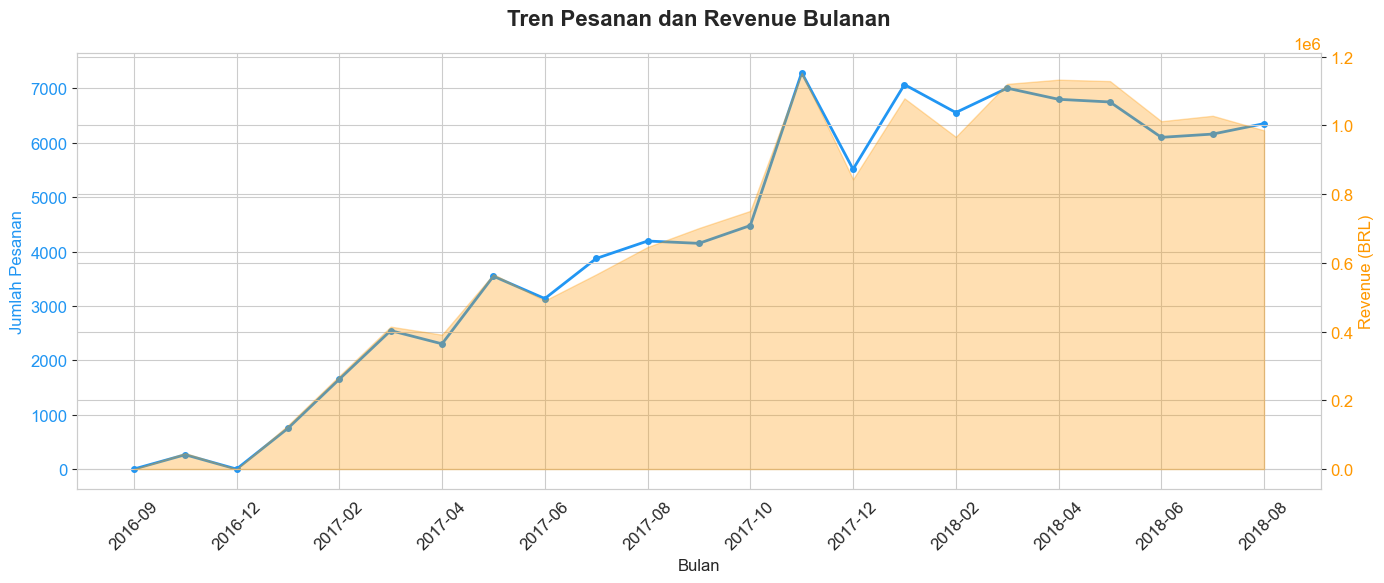

In [14]:
# Tren pesanan bulanan
all_orders_df['order_month'] = all_orders_df['order_purchase_timestamp'].dt.to_period('M')
monthly_orders = all_orders_df.groupby('order_month').agg(
    total_orders=('order_id', 'count'),
    total_revenue=('payment_value', 'sum')
).reset_index()
monthly_orders['order_month'] = monthly_orders['order_month'].astype(str)

fig, ax1 = plt.subplots(figsize=(14, 6))

color1 = '#2196F3'
ax1.set_xlabel('Bulan', fontsize=12)
ax1.set_ylabel('Jumlah Pesanan', color=color1, fontsize=12)
ax1.plot(monthly_orders['order_month'], monthly_orders['total_orders'],
         color=color1, linewidth=2, marker='o', markersize=4, label='Jumlah Pesanan')
ax1.tick_params(axis='y', labelcolor=color1)
ax1.tick_params(axis='x', rotation=45)

# Set x-axis to show every 2nd label to avoid overcrowding
ax1.xaxis.set_major_locator(ticker.MultipleLocator(2))

color2 = '#FF9800'
ax2 = ax1.twinx()
ax2.set_ylabel('Revenue (BRL)', color=color2, fontsize=12)
ax2.fill_between(range(len(monthly_orders)), monthly_orders['total_revenue'],
                 alpha=0.3, color=color2, label='Revenue')
ax2.tick_params(axis='y', labelcolor=color2)

plt.title('Tren Pesanan dan Revenue Bulanan', fontsize=16, fontweight='bold', pad=20)
fig.tight_layout()
plt.show()

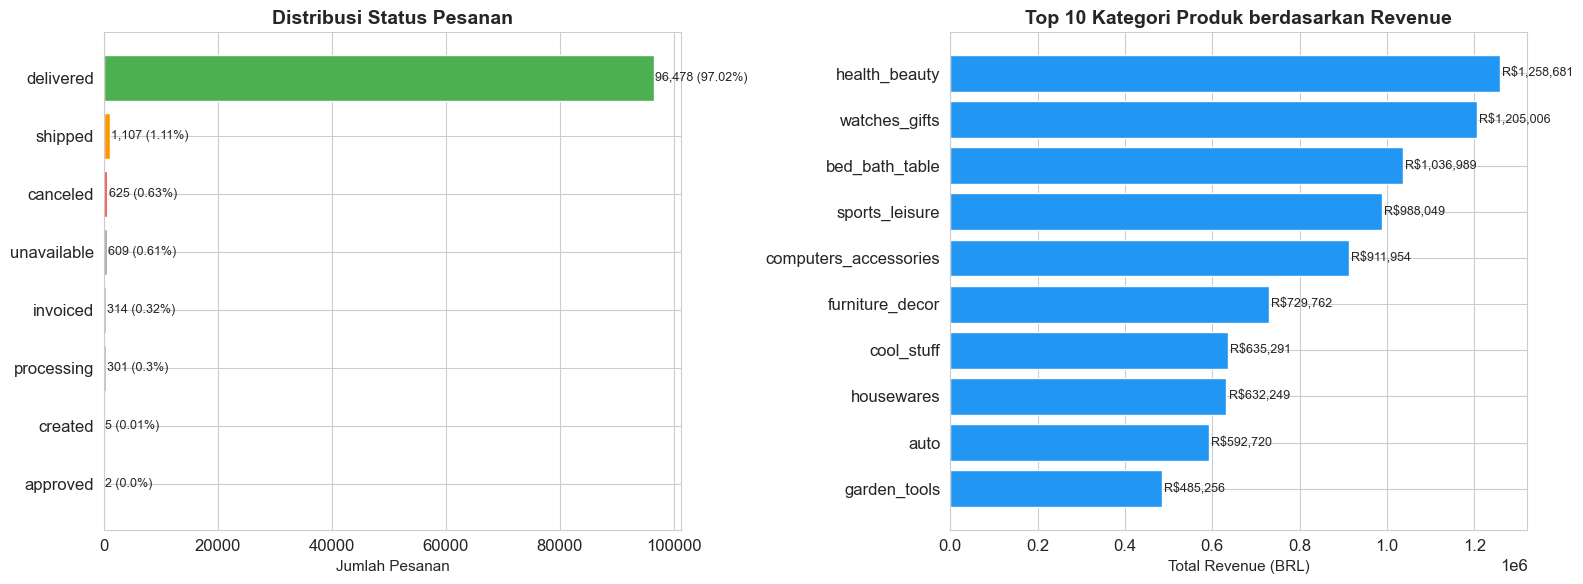

In [15]:
# Distribusi status pesanan
status_counts = orders_df['order_status'].value_counts()
status_pct = (status_counts / status_counts.sum() * 100).round(2)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart untuk status pesanan (lebih bersih dari pie chart karena 'delivered' mendominasi 97%)
colors_status = ['#4CAF50' if s == 'delivered' else '#FF9800' if s == 'shipped' else '#F44336' if s == 'canceled' else '#9E9E9E'
                 for s in status_counts.index]
bars = axes[0].barh(status_counts.index[::-1], status_counts.values[::-1],
                    color=colors_status[::-1], edgecolor='white')
axes[0].set_xlabel('Jumlah Pesanan', fontsize=11)
axes[0].set_title('Distribusi Status Pesanan', fontsize=14, fontweight='bold')
for i, (v, p) in enumerate(zip(status_counts.values[::-1], status_pct.values[::-1])):
    axes[0].text(v + 200, i, f'{v:,} ({p}%)', va='center', fontsize=9)

# Top 10 product categories by revenue
items_products_df = order_items_df.merge(products_full_df[['product_id', 'product_category_name_english']], on='product_id', how='left')
category_revenue = items_products_df.groupby('product_category_name_english')['price'].sum().sort_values(ascending=False).head(10)

axes[1].barh(category_revenue.index[::-1], category_revenue.values[::-1], color='#2196F3', edgecolor='white')
axes[1].set_xlabel('Total Revenue (BRL)', fontsize=11)
axes[1].set_title('Top 10 Kategori Produk berdasarkan Revenue', fontsize=14, fontweight='bold')
for i, v in enumerate(category_revenue.values[::-1]):
    axes[1].text(v + 5000, i, f'R${v:,.0f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

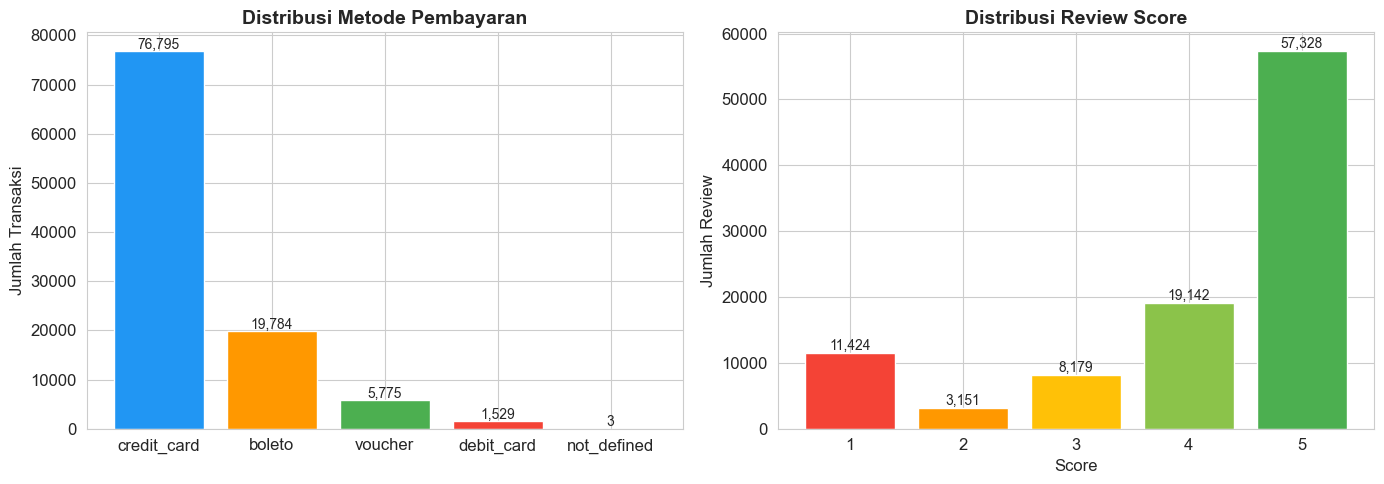

In [16]:
# Distribusi metode pembayaran
payment_type_counts = order_payments_df['payment_type'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors_pay = ['#2196F3', '#FF9800', '#4CAF50', '#F44336', '#9C27B0']
axes[0].bar(payment_type_counts.index, payment_type_counts.values, color=colors_pay[:len(payment_type_counts)])
axes[0].set_title('Distribusi Metode Pembayaran', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Jumlah Transaksi')
for i, v in enumerate(payment_type_counts.values):
    axes[0].text(i, v + 500, f'{v:,}', ha='center', fontsize=10)

# Distribusi review score
review_counts = order_reviews_df['review_score'].value_counts().sort_index()
colors_review = ['#F44336', '#FF9800', '#FFC107', '#8BC34A', '#4CAF50']
axes[1].bar(review_counts.index, review_counts.values, color=colors_review)
axes[1].set_title('Distribusi Review Score', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Score')
axes[1].set_ylabel('Jumlah Review')
for i, v in zip(review_counts.index, review_counts.values):
    axes[1].text(i, v + 500, f'{v:,}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

**Insight:**
- Tren pesanan menunjukkan pertumbuhan signifikan dari akhir 2016 hingga awal 2018, dengan puncak di sekitar November 2017 (kemungkinan Black Friday).
- Mayoritas pesanan (97%+) berstatus `delivered`, menunjukkan tingkat keberhasilan pengiriman yang tinggi.
- Kategori produk teratas berdasarkan revenue adalah `bed_bath_table`, `health_beauty`, dan `sports_leisure`.
- Credit card adalah metode pembayaran yang paling populer (75%+ transaksi).
- Distribusi review score didominasi oleh score 5 dan 4, menunjukkan kepuasan pelanggan yang tinggi.

## Visualization & Explanatory Analysis

### Pertanyaan 1: Bagaimana segmentasi pelanggan berdasarkan perilaku pembelian menggunakan RFM Analysis?

RFM Analysis adalah teknik segmentasi pelanggan berdasarkan tiga faktor utama:
- **Recency (R):** Berapa hari sejak terakhir kali pelanggan melakukan pembelian
- **Frequency (F):** Berapa kali pelanggan melakukan pembelian
- **Monetary (M):** Berapa total nilai pembelian pelanggan

Teknik ini membantu bisnis mengidentifikasi pelanggan terbaik, pelanggan yang berisiko pergi, dan pelanggan yang sudah tidak aktif.

In [17]:
# Hitung RFM metrics per customer
# Gunakan customer_unique_id (bukan customer_id) karena satu customer bisa punya multiple customer_id
reference_date = all_orders_df['order_purchase_timestamp'].max() + pd.Timedelta(days=1)
print(f'Reference date for Recency: {reference_date}')

rfm_df = all_orders_df.groupby('customer_unique_id').agg({
    'order_purchase_timestamp': lambda x: (reference_date - x.max()).days,  # Recency
    'order_id': 'nunique',  # Frequency
    'payment_value': 'sum'  # Monetary
}).reset_index()

rfm_df.rename(columns={
    'order_purchase_timestamp': 'recency',
    'order_id': 'frequency',
    'payment_value': 'monetary'
}, inplace=True)

print(f'\nTotal unique customers: {rfm_df.shape[0]}')
print(f'\nRFM Statistics:')
rfm_df[['recency', 'frequency', 'monetary']].describe()

Reference date for Recency: 2018-08-30 15:00:37



Total unique customers: 93358

RFM Statistics:


,recency,frequency,monetary
count,93358.000000,93358.000000,93358.000000
mean,237.941773,1.033420,165.197003
std,152.591453,0.209097,226.314012
min,1.000000,1.000000,0.000000
25%,114.000000,1.000000,63.052500
50%,219.000000,1.000000,107.780000
75%,346.000000,1.000000,182.557500
max,714.000000,15.000000,13664.080000


In [18]:
# Scoring RFM (1-5 menggunakan quantile)
# Recency: semakin kecil semakin baik → score terbalik
rfm_df['r_score'] = pd.qcut(rfm_df['recency'], q=5, labels=[5, 4, 3, 2, 1]).astype(int)

# Frequency: banyak customer dengan frequency = 1, gunakan rank method
rfm_df['f_score'] = pd.qcut(rfm_df['frequency'].rank(method='first'), q=5, labels=[1, 2, 3, 4, 5]).astype(int)

# Monetary: semakin besar semakin baik
rfm_df['m_score'] = pd.qcut(rfm_df['monetary'], q=5, labels=[1, 2, 3, 4, 5]).astype(int)

# Gabungkan score menjadi string RFM
rfm_df['rfm_score'] = rfm_df['r_score'].astype(str) + rfm_df['f_score'].astype(str) + rfm_df['m_score'].astype(str)

print('RFM Scores (sample):')
rfm_df[['customer_unique_id', 'recency', 'frequency', 'monetary', 'r_score', 'f_score', 'm_score', 'rfm_score']].head(10)

RFM Scores (sample):


,customer_unique_id,recency,frequency,monetary,r_score,f_score,m_score,rfm_score
0,0000366f3b9a7992bf8c76cfdf3221e2,112,1,141.90,4,1,4,414
1,0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,27.19,4,1,1,411
2,0000f46a3911fa3c0805444483337064,537,1,86.22,1,1,2,112
3,0000f6ccb0745a6a4b88665a16c9f078,321,1,43.62,2,1,1,211
4,0004aac84e0df4da2b147fca70cf8255,288,1,196.89,2,1,4,214
5,0004bd2a26a76fe21f786e4fbd80607f,146,1,166.98,4,1,4,414
6,00050ab1314c0e55a6ca13cf7181fecf,132,1,35.38,4,1,1,411
7,00053a61a98854899e70ed204dd4bafe,183,1,419.18,3,1,5,315
8,0005e1862207bf6ccc02e4228effd9a0,543,1,150.12,1,1,4,114
9,0005ef4cd20d2893f0d9fbd94d3c0d97,170,1,129.76,4,1,3,413


In [19]:
# Segmentasi pelanggan berdasarkan RFM Score (menggunakan Binning - Manual Grouping)
def rfm_segment(row):
    """Klasifikasikan pelanggan ke segmen berdasarkan skor RFM."""
    r, f, m = row['r_score'], row['f_score'], row['m_score']
    
    if r >= 4 and f >= 4 and m >= 4:
        return 'Champions'
    elif r >= 3 and f >= 3 and m >= 3:
        return 'Loyal Customers'
    elif r >= 4 and f <= 2:
        return 'New Customers'
    elif r >= 3 and f >= 1 and m >= 2:
        return 'Potential Loyalists'
    elif r <= 2 and f >= 3 and m >= 3:
        return 'At Risk'
    elif r <= 2 and f >= 4 and m >= 4:
        return "Can't Lose Them"
    elif r <= 2 and f <= 2:
        return 'Hibernating'
    else:
        return 'Need Attention'

rfm_df['segment'] = rfm_df.apply(rfm_segment, axis=1)

segment_counts = rfm_df['segment'].value_counts()
print('Distribusi Segmen Pelanggan:')
print(segment_counts)
print(f'\nTotal customers: {rfm_df.shape[0]}')

Distribusi Segmen Pelanggan:
segment
Need Attention         17359
Hibernating            14986
New Customers          14984
Loyal Customers        14209
At Risk                13165
Potential Loyalists    12162
Champions               6493
Name: count, dtype: int64

Total customers: 93358


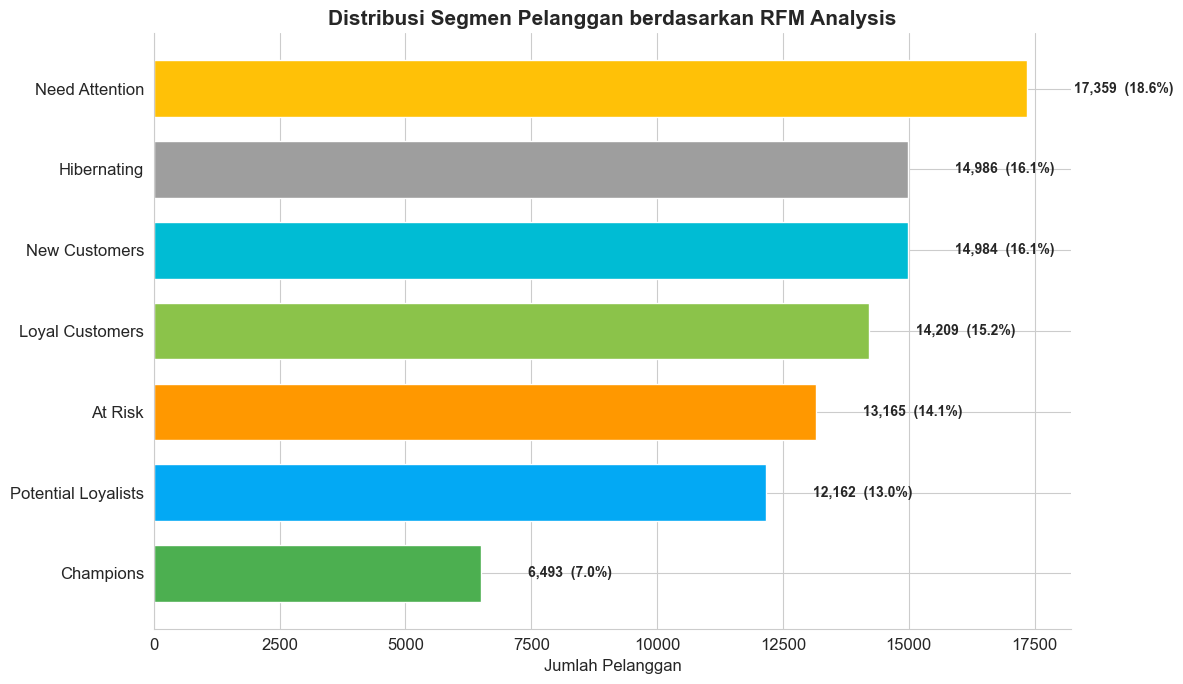

In [20]:
# Visualisasi 1: Distribusi segmen pelanggan
fig, ax = plt.subplots(figsize=(12, 7))

# Color mapping per segment
segment_colors = {
    'Champions': '#4CAF50',
    'Loyal Customers': '#8BC34A',
    'Potential Loyalists': '#03A9F4',
    'New Customers': '#00BCD4',
    'Need Attention': '#FFC107',
    'At Risk': '#FF9800',
    "Can't Lose Them": '#FF5722',
    'Hibernating': '#9E9E9E'
}

# Sort by count descending, then reverse for barh (top = largest)
sorted_segments = segment_counts.sort_values(ascending=True)
colors = [segment_colors.get(seg, '#9E9E9E') for seg in sorted_segments.index]
bars = ax.barh(sorted_segments.index, sorted_segments.values, color=colors, edgecolor='white', height=0.7)

ax.set_xlabel('Jumlah Pelanggan', fontsize=12)
ax.set_title('Distribusi Segmen Pelanggan berdasarkan RFM Analysis', fontsize=15, fontweight='bold')

# Annotasi: jumlah dan persentase
total = rfm_df.shape[0]
for i, (seg, v) in enumerate(sorted_segments.items()):
    pct = v / total * 100
    ax.text(v + total*0.01, i, f'{v:,}  ({pct:.1f}%)', va='center', fontsize=10, fontweight='bold')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

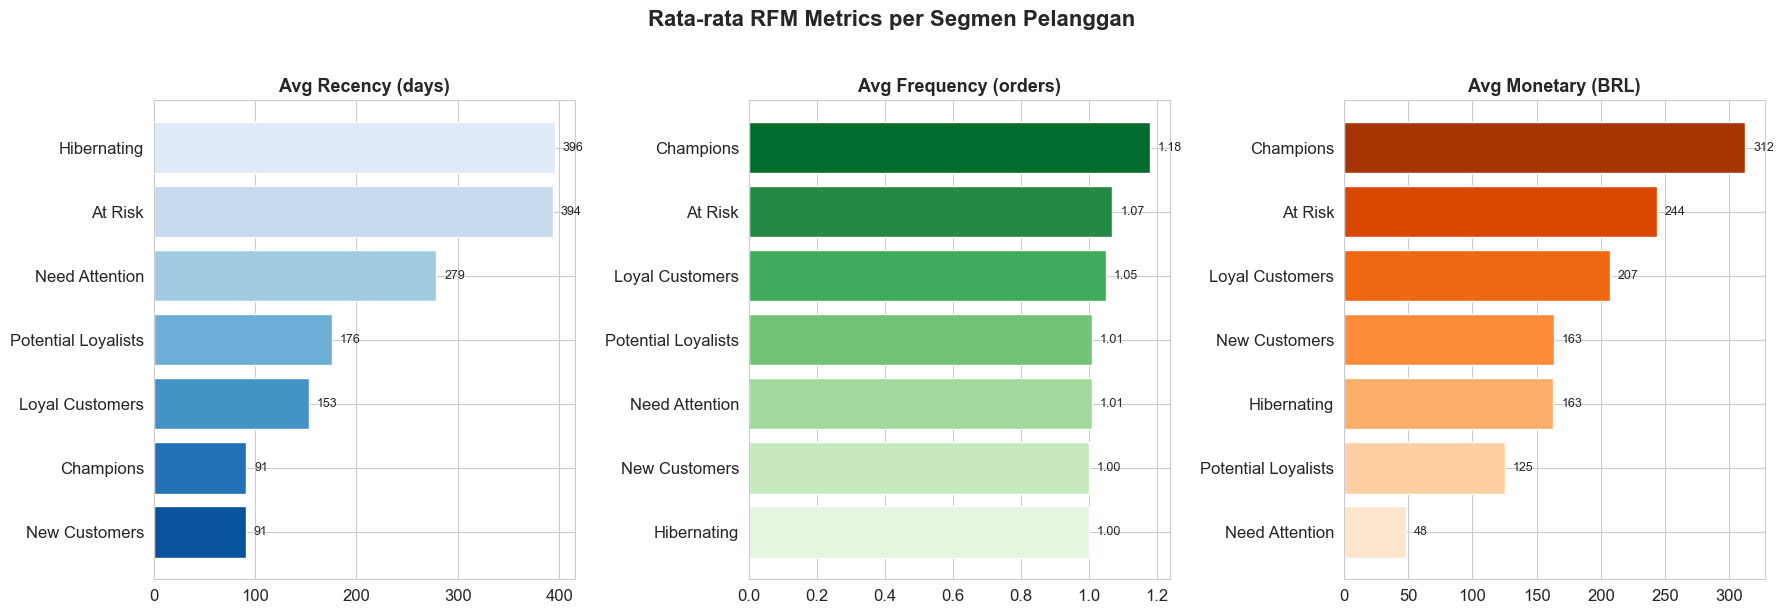

In [21]:
# Visualisasi 2: Rata-rata RFM per segmen
segment_rfm = rfm_df.groupby('segment').agg({
    'recency': 'mean',
    'frequency': 'mean',
    'monetary': 'mean'
}).round(2)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

metrics = ['recency', 'frequency', 'monetary']
titles = ['Avg Recency (days)', 'Avg Frequency (orders)', 'Avg Monetary (BRL)']
palettes = ['Blues_r', 'Greens', 'Oranges']

for ax, metric, title, palette in zip(axes, metrics, titles, palettes):
    sorted_data = segment_rfm[metric].sort_values(ascending=True)
    colors = sns.color_palette(palette, len(sorted_data))
    ax.barh(sorted_data.index, sorted_data.values, color=colors)
    ax.set_title(title, fontsize=13, fontweight='bold')
    for i, v in enumerate(sorted_data.values):
        label = f'{v:,.0f}' if metric != 'frequency' else f'{v:.2f}'
        ax.text(v + (sorted_data.max() * 0.02), i, label, va='center', fontsize=9)

plt.suptitle('Rata-rata RFM Metrics per Segmen Pelanggan', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Pertanyaan 2: Bagaimana distribusi geografis pelanggan dan seller, serta pengaruh lokasi terhadap volume pesanan?

Pada bagian ini, kita akan menganalisis distribusi geografis dari pelanggan dan seller menggunakan data geolocation yang tersedia. Analisis ini bertujuan untuk mengidentifikasi konsentrasi pasar dan peluang ekspansi.

In [22]:
# Hitung jumlah pesanan per state (customer)
customer_state_orders = all_orders_df.groupby('customer_state').agg(
    total_orders=('order_id', 'count'),
    total_revenue=('payment_value', 'sum'),
    unique_customers=('customer_unique_id', 'nunique')
).reset_index().sort_values('total_orders', ascending=False)

print('Top 10 States berdasarkan Jumlah Pesanan:')
customer_state_orders.head(10)

Top 10 States berdasarkan Jumlah Pesanan:


,customer_state,total_orders,total_revenue,unique_customers
25,SP,40501,5770266.19,39156
18,RJ,12350,2055690.45,11917
10,MG,11354,1819277.61,11001
22,RS,5345,861802.40,5168
17,PR,4923,781919.55,4769
23,SC,3546,595208.40,3449
4,BA,3256,591270.60,3158
6,DF,2080,346146.17,2019
7,ES,1995,317682.65,1928
8,GO,1957,334294.22,1895


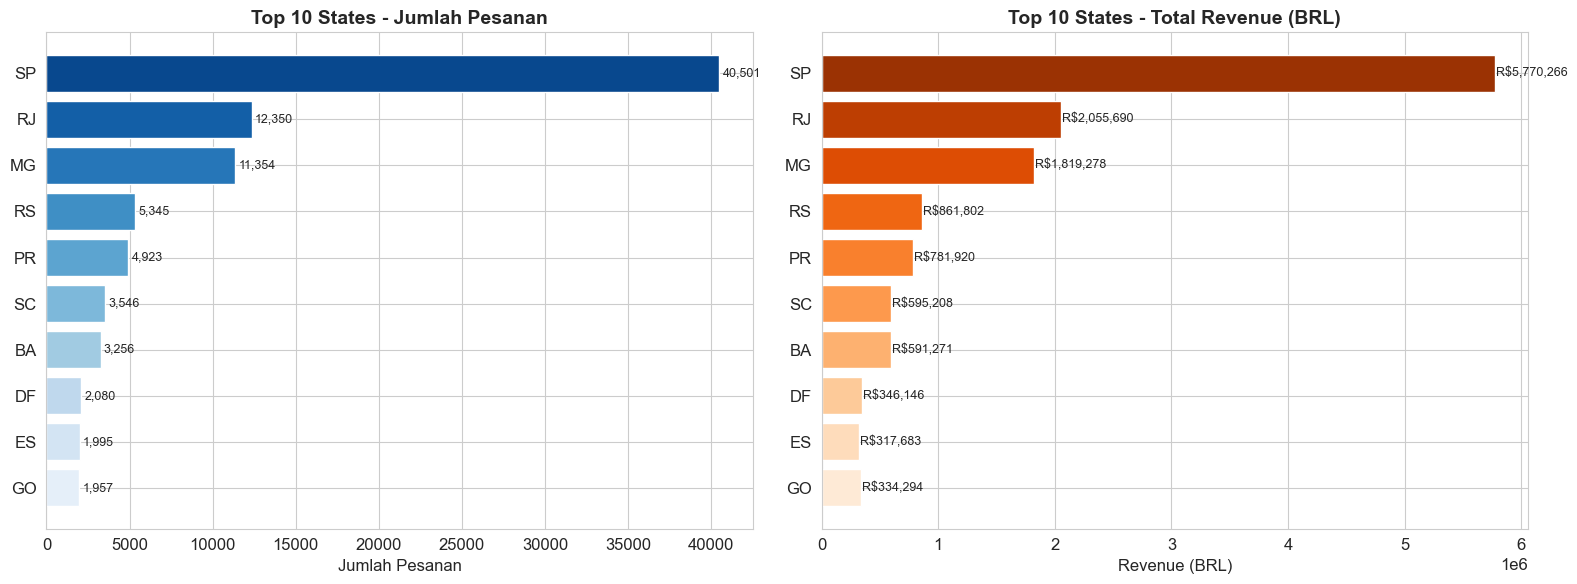

In [23]:
# Visualisasi: Top 10 states by orders & revenue
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top10_states = customer_state_orders.head(10)

# Orders
colors_gradient = sns.color_palette('Blues_r', 10)
axes[0].barh(top10_states['customer_state'][::-1], top10_states['total_orders'][::-1],
             color=colors_gradient[::-1])
axes[0].set_title('Top 10 States - Jumlah Pesanan', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Jumlah Pesanan')
for i, v in enumerate(top10_states['total_orders'][::-1].values):
    axes[0].text(v + 200, i, f'{v:,}', va='center', fontsize=9)

# Revenue
colors_gradient2 = sns.color_palette('Oranges_r', 10)
axes[1].barh(top10_states['customer_state'][::-1], top10_states['total_revenue'][::-1],
             color=colors_gradient2[::-1])
axes[1].set_title('Top 10 States - Total Revenue (BRL)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Revenue (BRL)')
for i, v in enumerate(top10_states['total_revenue'][::-1].values):
    axes[1].text(v + 10000, i, f'R${v:,.0f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

In [24]:
# Analisis distribusi seller per state
seller_state_counts = sellers_df.groupby('seller_state').agg(
    total_sellers=('seller_id', 'count')
).reset_index().sort_values('total_sellers', ascending=False)

# Gabungkan data customer dan seller per state
state_comparison = customer_state_orders[['customer_state', 'total_orders', 'unique_customers']].merge(
    seller_state_counts.rename(columns={'seller_state': 'customer_state'}),
    on='customer_state',
    how='outer'
).fillna(0).sort_values('total_orders', ascending=False)

print('Perbandingan Customers vs Sellers per State (Top 10):')
state_comparison.head(10)

Perbandingan Customers vs Sellers per State (Top 10):


,customer_state,total_orders,unique_customers,total_sellers
25,SP,40501,39156,1849.0
18,RJ,12350,11917,171.0
10,MG,11354,11001,244.0
22,RS,5345,5168,129.0
17,PR,4923,4769,349.0
23,SC,3546,3449,190.0
4,BA,3256,3158,19.0
6,DF,2080,2019,30.0
7,ES,1995,1928,23.0
8,GO,1957,1895,40.0


In [25]:
# Geospatial Analysis - Map distribusi pelanggan
# Merge customer data dengan geolocation
customer_geo = all_orders_df.merge(
    geo_clean_df.rename(columns={'geolocation_zip_code_prefix': 'customer_zip_code_prefix'}),
    on='customer_zip_code_prefix',
    how='inner'
)

# Aggregate per city
city_orders = customer_geo.groupby(['geolocation_city', 'geolocation_state']).agg(
    total_orders=('order_id', 'count'),
    avg_lat=('geolocation_lat', 'mean'),
    avg_lng=('geolocation_lng', 'mean')
).reset_index().sort_values('total_orders', ascending=False)

print(f'Total cities with orders: {city_orders.shape[0]}')
city_orders.head(10)

Total cities with orders: 4332


,geolocation_city,geolocation_state,total_orders,avg_lat,avg_lng
3715,sao paulo,SP,12792,-23.572128,-46.632026
3271,rio de janeiro,RJ,6592,-22.922862,-43.323030
464,belo horizonte,MG,2697,-19.909155,-43.956656
3932,são paulo,SP,2251,-23.570712,-46.642679
1180,curitiba,PR,1489,-25.453307,-49.274048
583,brasilia,DF,1449,-15.807034,-47.969909
736,campinas,SP,1406,-22.902348,-47.075245
3064,porto alegre,RS,1342,-30.049828,-51.187045
3367,salvador,BA,1185,-12.959245,-38.457699
1583,guarulhos,SP,1144,-23.444772,-46.497816


In [26]:
# Buat folium map - Distribusi Pelanggan
brazil_center = [-14.235, -51.9253]
m = folium.Map(location=brazil_center, zoom_start=4, tiles='CartoDB positron')

# Tambahkan marker untuk top 50 cities
top_cities = city_orders.head(50)
for _, row in top_cities.iterrows():
    folium.CircleMarker(
        location=[row['avg_lat'], row['avg_lng']],
        radius=max(3, min(row['total_orders'] / 200, 25)),
        color='#2196F3',
        fill=True,
        fill_color='#2196F3',
        fill_opacity=0.6,
        popup=f"{row['geolocation_city']}-{row['geolocation_state']}: {row['total_orders']:,} orders"
    ).add_to(m)

# Tambahkan seller locations
seller_geo = sellers_df.merge(
    geo_clean_df.rename(columns={'geolocation_zip_code_prefix': 'seller_zip_code_prefix'}),
    on='seller_zip_code_prefix',
    how='inner'
)

seller_city_counts = seller_geo.groupby(['geolocation_city', 'geolocation_state']).agg(
    total_sellers=('seller_id', 'count'),
    avg_lat=('geolocation_lat', 'mean'),
    avg_lng=('geolocation_lng', 'mean')
).reset_index().sort_values('total_sellers', ascending=False)

for _, row in seller_city_counts.head(30).iterrows():
    folium.CircleMarker(
        location=[row['avg_lat'], row['avg_lng']],
        radius=max(3, min(row['total_sellers'] / 10, 20)),
        color='#FF5722',
        fill=True,
        fill_color='#FF5722',
        fill_opacity=0.6,
        popup=f"Sellers in {row['geolocation_city']}-{row['geolocation_state']}: {row['total_sellers']}"
    ).add_to(m)

# Legend
legend_html = '''
<div style="position: fixed; bottom: 50px; left: 50px; z-index:9999;
            background-color: white; padding: 10px; border: 2px solid grey; border-radius: 5px;">
    <p style="margin: 0;"><span style="color:#2196F3;">●</span> Customers</p>
    <p style="margin: 0;"><span style="color:#FF5722;">●</span> Sellers</p>
</div>
'''
m.get_root().html.add_child(folium.Element(legend_html))

m

**Insight:**
- São Paulo (SP) mendominasi baik dari sisi pelanggan maupun seller, diikuti Rio de Janeiro (RJ) dan Minas Gerais (MG).
- Terdapat konsentrasi yang sangat tinggi di wilayah tenggara Brasil (São Paulo, Rio de Janeiro, Belo Horizonte).
- Seller juga terkonsentrasi di São Paulo, yang menjelaskan mengapa waktu pengiriman ke wilayah ini cenderung lebih cepat.
- Wilayah utara dan barat daya Brasil memiliki jumlah pesanan yang sangat sedikit — potensi area untuk ekspansi pasar.
- Ada ketidakseimbangan antara jumlah customer dan seller di beberapa state (contoh: beberapa state memiliki banyak customer tapi sedikit seller).

## Analisis Lanjutan

Pada bagian ini, kita menerapkan tiga teknik analisis lanjutan:
1. **RFM Analysis** — telah dilakukan di bagian Pertanyaan 1
2. **Geospatial Analysis** — telah dilakukan di bagian Pertanyaan 2 menggunakan folium
3. **Clustering (Manual Grouping / Binning)** — mengelompokkan pelanggan berdasarkan skor RFM tanpa menggunakan algoritma machine learning

### Penjelasan Teknik Analisis Lanjutan

**1. RFM Analysis**
- **Tujuan:** Mengelompokkan pelanggan berdasarkan perilaku pembelian mereka (Recency, Frequency, Monetary)
- **Metode:** Menghitung ketiga metrik per pelanggan, kemudian memberikan skor 1-5 menggunakan quantile

**2. Geospatial Analysis**
- **Tujuan:** Menganalisis distribusi geografis pelanggan dan seller untuk mengidentifikasi tren lokasi
- **Metode:** Menggunakan folium untuk membuat peta interaktif yang menampilkan distribusi data berdasarkan lokasi

**3. Clustering (Binning)**
- **Tujuan:** Mengelompokkan pelanggan ke dalam segmen berdasarkan aturan bisnis
- **Metode:** Manual Grouping — mendefinisikan kriteria segmen berdasarkan kombinasi skor R, F, dan M tanpa menggunakan algoritma machine learning

In [27]:
# Analisis detail per segmen
segment_analysis = rfm_df.groupby('segment').agg({
    'recency': ['mean', 'median'],
    'frequency': ['mean', 'median', 'max'],
    'monetary': ['mean', 'median', 'sum'],
    'customer_unique_id': 'count'
}).round(2)

segment_analysis.columns = [
    'avg_recency', 'median_recency',
    'avg_frequency', 'median_frequency', 'max_frequency',
    'avg_monetary', 'median_monetary', 'total_monetary',
    'customer_count'
]

# Hitung persentase revenue
segment_analysis['revenue_pct'] = (segment_analysis['total_monetary'] / segment_analysis['total_monetary'].sum() * 100).round(1)

print('Detail Analisis per Segmen:')
segment_analysis.sort_values('total_monetary', ascending=False)

Detail Analisis per Segmen:


,avg_recency,median_recency,avg_frequency,median_frequency,max_frequency,avg_monetary,median_monetary,total_monetary,customer_count,revenue_pct
segment,,,,,,,,,,
At Risk,393.50,379.0,1.07,1.0,6,243.52,163.06,3205984.21,13165,20.8
Loyal Customers,153.23,170.0,1.05,1.0,9,207.14,137.99,2943315.48,14209,19.1
New Customers,90.88,93.0,1.00,1.0,1,163.43,108.76,2448804.73,14984,15.9
Hibernating,395.51,384.0,1.00,1.0,1,162.96,104.37,2442132.02,14986,15.8
Champions,91.11,91.0,1.18,1.0,15,312.13,211.85,2026656.84,6493,13.1
Potential Loyalists,175.68,197.0,1.01,1.0,2,125.06,78.70,1520966.29,12162,9.9
Need Attention,278.77,275.0,1.01,1.0,4,48.08,45.48,834602.20,17359,5.4


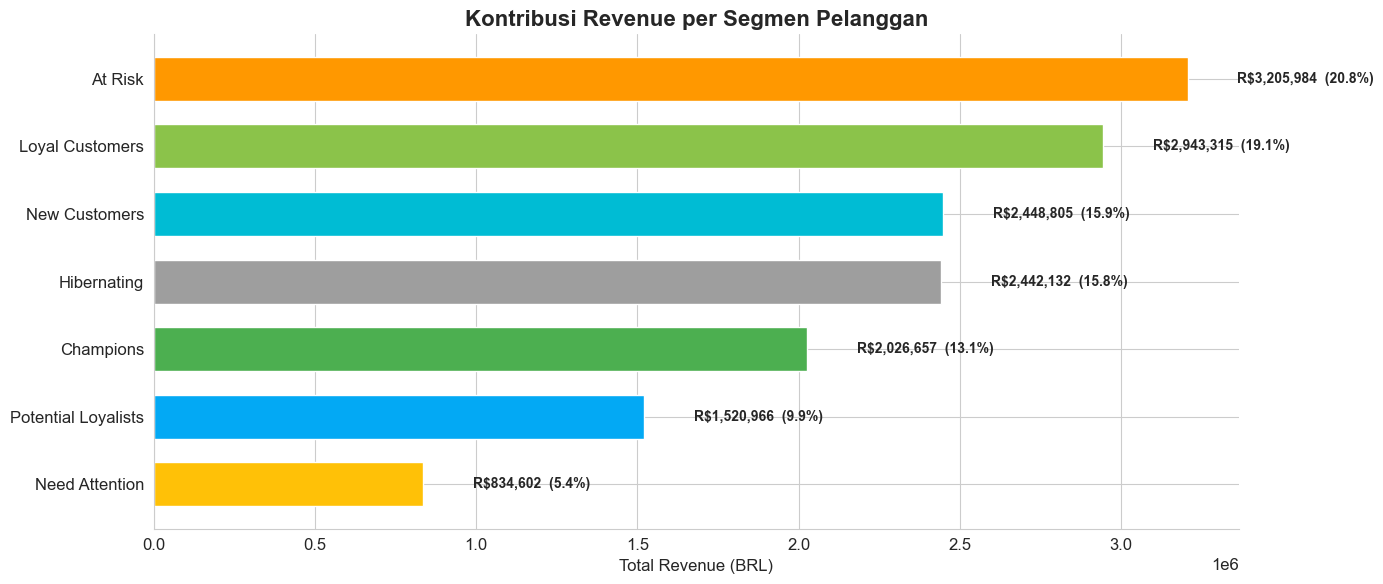

In [28]:
# Visualisasi: Kontribusi Revenue per Segmen Pelanggan
fig, ax = plt.subplots(figsize=(14, 6))

seg_revenue = rfm_df.groupby('segment')['monetary'].sum().sort_values(ascending=True)
total_revenue = seg_revenue.sum()

# Horizontal bar chart per segmen
colors = [segment_colors.get(seg, '#9E9E9E') for seg in seg_revenue.index]
bars = ax.barh(seg_revenue.index, seg_revenue.values, color=colors, edgecolor='white', height=0.65)

ax.set_xlabel('Total Revenue (BRL)', fontsize=12)
ax.set_title('Kontribusi Revenue per Segmen Pelanggan', fontsize=16, fontweight='bold')

# Annotasi: revenue dan persentase
for i, (seg, val) in enumerate(seg_revenue.items()):
    pct = val / total_revenue * 100
    ax.text(val + total_revenue * 0.01, i, f'R${val:,.0f}  ({pct:.1f}%)',
            va='center', fontsize=10, fontweight='bold')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

In [29]:
# Simpan data RFM untuk dashboard
rfm_df.to_csv('dashboard/rfm_data.csv', index=False)
print(f'RFM data saved: {rfm_df.shape}')

# Simpan data geolocation per city untuk dashboard
city_orders.to_csv('dashboard/city_orders.csv', index=False)
seller_city_counts.to_csv('dashboard/seller_city_counts.csv', index=False)
print(f'City orders data saved: {city_orders.shape}')
print(f'Seller city data saved: {seller_city_counts.shape}')

RFM data saved: (93358, 9)
City orders data saved: (4332, 5)
Seller city data saved: (598, 5)


## Conclusion

### Kesimpulan Pertanyaan 1: Segmentasi Pelanggan (RFM Analysis)

Berdasarkan analisis RFM yang telah dilakukan, pelanggan E-Commerce berhasil dikelompokkan ke dalam beberapa segmen:

- **Champions & Loyal Customers** — Merupakan pelanggan terbaik yang memiliki recency rendah (baru-baru ini membeli), frequency tinggi, dan monetary tinggi. Mereka berkontribusi signifikan terhadap total revenue.
- **Potential Loyalists & New Customers** — Pelanggan baru yang berpotensi menjadi loyal. Perlu diperhatikan dengan program engagement dan loyalty.
- **At Risk & Can't Lose Them** — Pelanggan yang dulunya aktif namun mulai jarang membeli. Perlu strategi win-back yang agresif.
- **Hibernating** — Pelanggan yang sudah lama tidak aktif. Perlu dievaluasi apakah layak untuk di-reactivasi.

**Rekomendasi:**
1. Berikan reward/loyalty program untuk segmen Champions
2. Kirim promosi khusus untuk segmen At Risk dan Can't Lose Them
3. Berikan first-purchase incentive untuk New Customers
4. Evaluasi cost-effectiveness dari reactivation campaigns untuk Hibernating customers

---

### Kesimpulan Pertanyaan 2: Distribusi Geografis

Analisis geospasial menunjukkan bahwa:

- **São Paulo (SP) adalah pusat e-commerce utama** — baik dari sisi pelanggan maupun seller, SP mendominasi dengan margin yang sangat besar.
- **Konsentrasi di wilayah tenggara** — SP, RJ, dan MG bersama-sama mewakili mayoritas volume pesanan.
- **Ketidakmerataan distribusi** — Wilayah utara dan barat daya Brasil memiliki penetrasi e-commerce yang masih sangat rendah.
- **Seller terkonsentrasi** — Mayoritas seller berada di SP, yang memengaruhi biaya dan waktu pengiriman ke wilayah lain.

**Rekomendasi:**
1. Ekspansi seller network ke wilayah dengan demand tinggi tapi seller sedikit (seperti beberapa state di luar SP)
2. Optimalkan logistik di wilayah luar Jawa (utara & barat daya Brasil) untuk menurunkan ongkos kirim
3. Fokuskan marketing digital di state-state dengan penetrasi e-commerce rendah untuk pertumbuhan pasar baru